# Gradient Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mean_squared_error(y_true, y_predicted):

    # Calculating the loss or cost
    cost = np.sum((y_true-y_predicted)**2) / len(y_true)
    return cost

# Gradient Descent Function
# Here iterations, learning_rate, stopping_threshold
# are hyperparameters that can be tuned
def gradient_descent(x, y, iterations = 1000, learning_rate = 0.0001,
                     stopping_threshold = 1e-6):

    # Initializing weight, bias, learning rate and iterations
    current_weight = 0.0
    current_bias = 0.8
    iterations = iterations
    learning_rate = learning_rate
    n = float(len(x))

    costs = []
    weights = []
    previous_cost = None

    # Estimation of optimal parameters
    for i in range(iterations):

        # Making predictions
        y_predicted = (current_weight * x) + current_bias

        # Calculationg the current cost
        current_cost = mean_squared_error(y, y_predicted)

        # If the change in cost is less than or equal to
        # stopping_threshold we stop the gradient descent
        if previous_cost and abs(previous_cost-current_cost)<=stopping_threshold:
            break

        previous_cost = current_cost

        costs.append(current_cost)
        weights.append(current_weight)

        # Calculating the gradients
        weight_derivative = -(2/n) * sum(x * (y-y_predicted))
        bias_derivative = -(2/n) * sum(y-y_predicted)

        # Updating weights and bias
        current_weight = current_weight - (learning_rate * weight_derivative)
        current_bias = current_bias - (learning_rate * bias_derivative)

        # Printing the parameters for each 1000th iteration
        print(f"Iteration {i+1}: Cost {current_cost}, Weight {current_weight}, Bias {current_bias}")

    return current_weight, current_bias

# Data
X = np.array([1, 2, 3, 4, 5])
Y = np.array([2, 5, 3, 8, 7])

# Estimating weight and bias using gradient descent
gd_weight, gd_bias = gradient_descent(X, Y, 2, 0.01)
print(f"Estimated Weight: {gd_weight}\nEstimated Bias: {gd_bias}")

# Making predictions using estimated parameters
gd_Y_pred = gd_weight*X + gd_bias
gd_Y_pred

Iteration 1: Cost 22.840000000000003, Weight 0.30400000000000005, Bias 0.884
Iteration 2: Cost 14.069648, Weight 0.53608, Bias 0.94808
Estimated Weight: 0.53608
Estimated Bias: 0.94808


array([1.48416, 2.02024, 2.55632, 3.0924 , 3.62848])

# Artificial Neural Network

In [2]:
import tensorflow as tf

import numpy as np
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

X = np.array([1, 2, 3, 4, 5],  dtype=float)
Y = np.array([2, 5, 3, 8, 7],  dtype=float)

ann_model = tf.keras.Sequential([
  tf.keras.layers.Dense(units=1, input_shape=[1])
])
ann_model.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(0.1))
history = ann_model.fit(X, Y, epochs=100, verbose=False)
print("Finished training the model")

ann_weight = ann_model.weights[0][0,0]
ann_bias = ann_model.weights[1][0]

ann_Y_pred = ann_weight*X + ann_bias
ann_Y_pred

Finished training the model


<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([2.4085822, 3.7068398, 5.0050974, 6.3033547, 7.601612 ],
      dtype=float32)>

# Convolutional Neural Network

In [3]:
import numpy as np
import tensorflow as tf

# Define the data
X = np.array([1, 2, 3, 4, 5], dtype=np.float32)
Y = np.array([2, 5, 3, 8, 7], dtype=np.float32)

# Reshape the data into a 3D array with one feature (i.e., a single column)
X = X.reshape(-1, 1, 1)

# Define the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(1, kernel_size=1, input_shape=(1, 1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X, Y, epochs=100, verbose=0)

# Get the weights and bias
cnn_weights = model.layers[0].get_weights()[0][0][0][0]
cnn_bias = model.layers[0].get_weights()[1][0]

cnn_Y_pred = cnn_weights*X + cnn_bias
cnn_Y_pred = cnn_Y_pred.flatten()
cnn_Y_pred

array([1.3813109, 2.8569083, 4.332505 , 5.8081026, 7.2837   ],
      dtype=float32)

# Plot

In [4]:
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5])
Y = np.array([2, 5, 3, 8, 7])

## GD

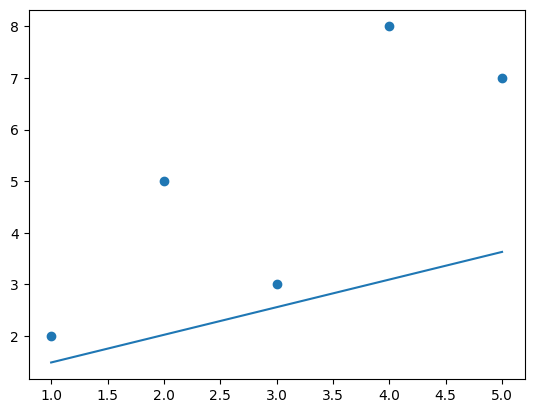

In [5]:
plt.scatter(X, Y)
plt.plot(X, gd_Y_pred)

## ANN

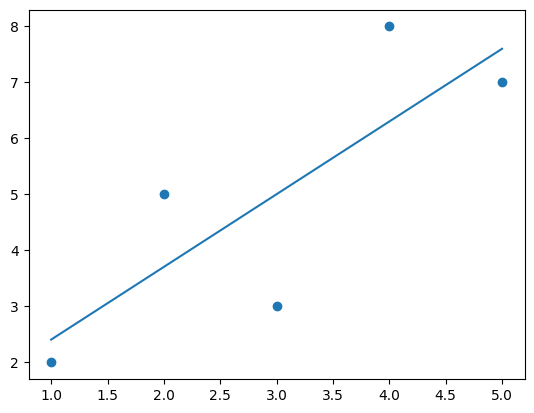

In [6]:
plt.scatter(X, Y)
plt.plot(X, ann_Y_pred)

## CNN

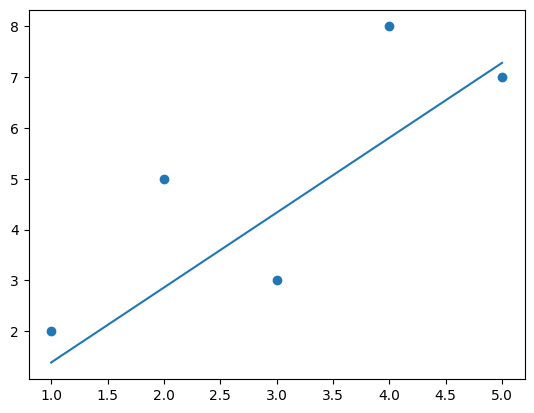

In [7]:
plt.scatter(X, Y)
plt.plot(X, cnn_Y_pred)